# Exploratory data analysis
### Alumno: Jorge Urbelz Alonso-Cortés

Create a notebook, load a dataset of your interest and apply techniques developed in along the lecture (summary statistics and/or graphical tools).
Remember that the goal of an exploratory analysis is not to provide a definitive answer to a question, but rather to get an insight to the data to better frame futher analysis. In other words, we want to describe our data instead of reaching solid conclusions.
You may want to consider the following structure to guide your EDA.

*   First contact
1.   Visualize your raw data.
2.   Count number of instances and attributes (rows and columns).
3.   Identify your variables.
4.   Find out if there are duplicates and NaNs and handle them.
5.   Get summary statistics (max, min, avg) and identify whether there are outlayers.
*   Visualize your variables distribution (univariable).
*   Identify correlations among your variables (bivariable).



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print(sns.__version__)

0.13.2


Vamos a cargar los datos del archivo de Exoplanetas de la NASA

In [ ]:
data = pd.read_csv("/content/data.csv")

In [ ]:
data.shape

(39476, 42)

Ahora, vamos a limpiar los datos, eliminando filas y columnas innecesarias. Comenzaremos eliminando las filas duplicadas

In [ ]:
data = data.drop_duplicates(subset ="pl_name")

In [ ]:
data.columns

Index(['pl_name', 'hostname', 'default_flag', 'sy_snum', 'sy_pnum',
       'discoverymethod', 'disc_year', 'disc_facility', 'soltype',
       'pl_controv_flag', 'pl_refname', 'pl_orbper', 'pl_orbsmax', 'pl_rade',
       'pl_radj', 'pl_bmasse', 'pl_bmassj', 'pl_bmassprov', 'pl_orbeccen',
       'pl_insol', 'pl_eqt', 'ttv_flag', 'st_refname', 'st_spectype',
       'st_teff', 'st_rad', 'st_mass', 'st_met', 'st_metratio', 'st_logg',
       'sy_refname', 'rastr', 'ra', 'decstr', 'dec', 'sy_dist', 'sy_vmag',
       'sy_kmag', 'sy_gaiamag', 'rowupdate', 'pl_pubdate',
       'releasedate;;;;;;;;;'],
      dtype='object')

Tenemos demasiadas columnas, algunas de las cuales no nos interesa seguir teniendo. Vamos a eliminarlas

In [ ]:
data = data.drop(["pl_controv_flag","pl_refname", "sy_refname", "st_refname", "rowupdate", "pl_pubdate", "ttv_flag", "default_flag", "releasedate;;;;;;;;;", "pl_bmassj", "pl_bmassprov", "pl_radj", "sy_vmag", "sy_kmag", "rastr", "decstr", "st_logg"], axis=1)

In [ ]:
data.shape

(6138, 25)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6138 entries, 0 to 39473
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pl_name          6138 non-null   object 
 1   hostname         6138 non-null   object 
 2   sy_snum          6138 non-null   int64  
 3   sy_pnum          6138 non-null   int64  
 4   discoverymethod  6138 non-null   object 
 5   disc_year        6137 non-null   float64
 6   disc_facility    6138 non-null   object 
 7   soltype          6138 non-null   object 
 8   pl_orbper        5540 non-null   float64
 9   pl_orbsmax       3787 non-null   float64
 10  pl_rade          3683 non-null   float64
 11  pl_bmasse        2238 non-null   float64
 12  pl_orbeccen      3143 non-null   float64
 13  pl_insol         2301 non-null   float64
 14  pl_eqt           2608 non-null   float64
 15  st_spectype      1097 non-null   object 
 16  st_teff          5264 non-null   float64
 17  st_rad           5

Con describe() podemos ver el recuento de cada columna junto con su valor medio, desviación estándar, valores mínimo y máximo.

In [ ]:
data.describe()

,sy_snum,sy_pnum,disc_year,pl_orbper,pl_orbsmax,pl_rade,pl_bmasse,pl_orbeccen,pl_insol,pl_eqt,st_teff,st_rad,st_mass,st_met,ra,dec,sy_dist,sy_gaiamag
count,6138.000000,6138.000000,6137.000000,5.540000e+03,3787.000000,3683.000000,2238.000000,3143.000000,2301.000000,2608.000000,5264.000000,5161.000000,5092.000000,3734.000000,6138.000000,6138.000000,6000.000000,5801.000000
mean,1.103780,1.775171,2016.968714,7.722163e+04,23.766809,5.262454,929.832855,0.102894,348.381435,892.324655,5392.670659,1.492461,0.934820,-0.009926,232.912408,18.127851,703.009848,12.256000
std,0.343209,1.159142,4.953730,5.403486e+06,432.843929,52.385316,1748.728458,0.172701,860.160193,450.289159,1468.526535,3.848802,0.425318,0.258489,91.725850,37.028024,1190.633740,2.960778
min,1.000000,1.000000,1992.000000,9.070629e-02,0.004400,0.276000,0.015000,0.000000,0.001600,50.000000,415.000000,0.012300,0.007700,-1.700000,0.185606,-88.121111,1.301190,2.364310
25%,1.000000,1.000000,2014.000000,4.345954e+00,0.059000,1.582000,14.407500,0.000000,20.260000,555.000000,4911.750000,0.762000,0.770000,-0.140000,173.213690,-11.027625,100.414325,10.365400
50%,1.000000,1.000000,2016.000000,1.108959e+01,0.126000,2.420000,216.061658,0.000000,83.707800,804.500000,5545.000000,0.950000,0.948000,0.000000,284.941063,39.149000,376.760500,12.968200
75%,1.000000,2.000000,2021.000000,4.018967e+01,0.780500,3.940000,945.540690,0.140000,329.340000,1146.000000,5911.000000,1.252310,1.080000,0.140000,293.248142,45.384333,832.662750,14.680300
max,4.000000,8.000000,2026.000000,4.020000e+08,19000.000000,3163.540000,22934.497849,0.956000,17123.005500,3053.000000,40000.000000,88.475000,10.830000,7.790000,359.974984,86.860343,8800.000000,20.186100


In [ ]:
data.dtypes

,0
pl_name,object
hostname,object
sy_snum,int64
sy_pnum,int64
discoverymethod,object
disc_year,float64
disc_facility,object
soltype,object
pl_orbper,float64
pl_orbsmax,float64


Vamos a mostrar un primer histograma, donde se muestra el año de descubrimiento de cada uno de los planetas que hay en el conjunto de datos. El aumento progresivo de descubrimientos se puede entender por la mejora de métodos de medicción y que cada vez hay más misiones espaciales dedicadas a la búsqueda de exoplanetas. Además, hemos dividido en columnas los planetas descubiertos, según el número de estrellas que hay en su sistema. Como vemos, el sistema por excelencia es el de un único sol, mientras que los sistemas trisolares son los menos comunes (será difícil encontrar algún trisolariano😉). Por último, solo se ha descubierto un planeta (en 2012) con 4 estrellas en su sistema. Estas primeras gráficas las hemos hecho antes de eliminar los nulos, ya que así contamos con más filas que utilizar en el estudio de exoplanetas descubiertos. No importa si falta algún dato trascendental, al principio solo nos interesa su descubrimiento.

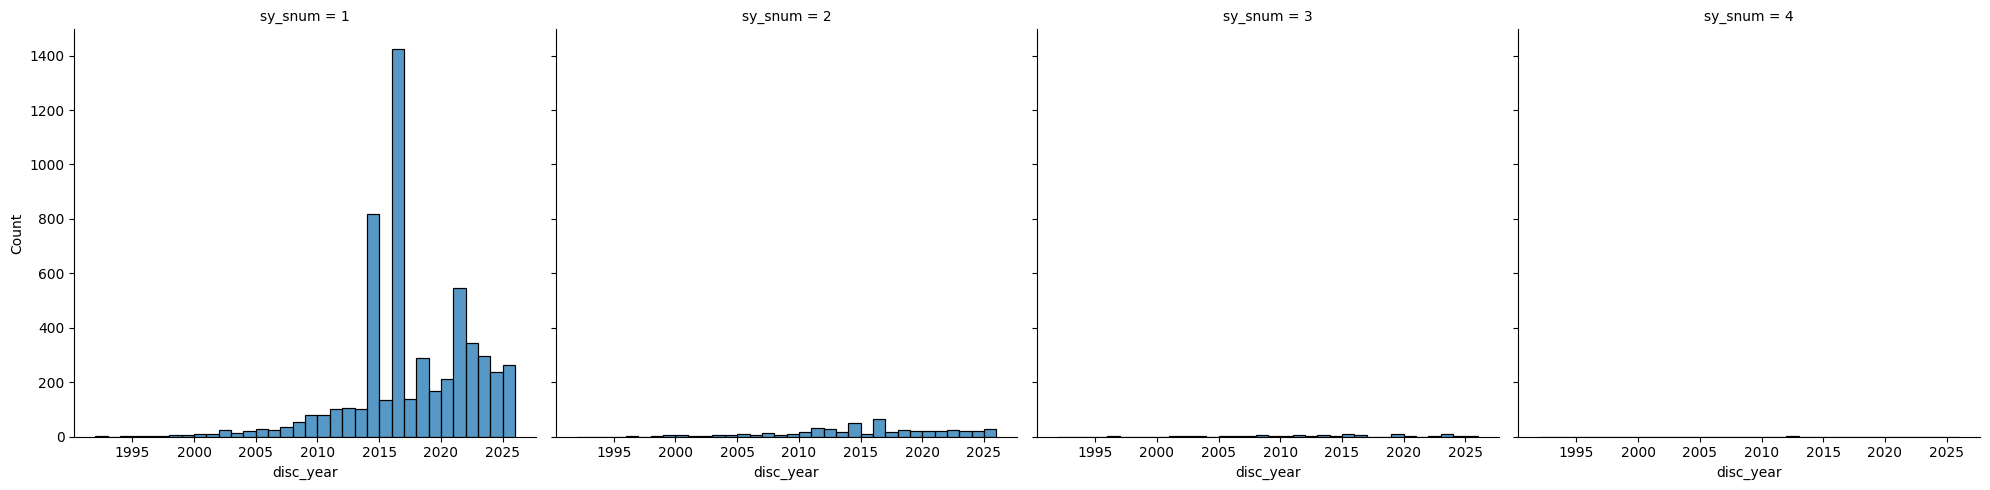

In [ ]:
values = {"disc_year": 2017}
data=data.fillna(value=values)
sns.displot(x="disc_year", col="sy_snum", data=data, binwidth=1);

También hemos dividido los exoplanetas descubiertos según el número de exoplanetas que hay en el sistema. Se han reportado sistemas estelares con hasta ocho exoplanetas

/tmp/ipykernel_8709/2632699191.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


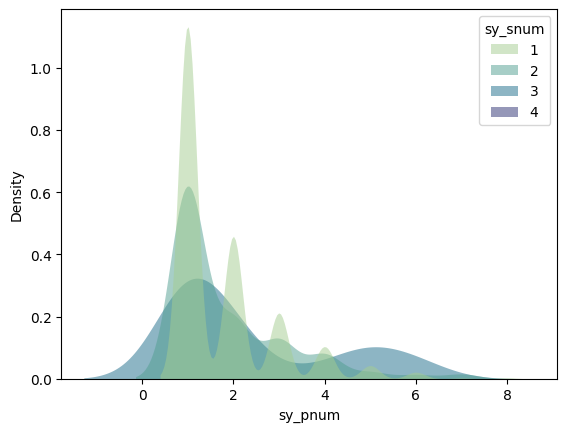

In [ ]:
sns.kdeplot(
   data=data, x="sy_pnum", hue="sy_snum",
   fill=True, common_norm=False, palette="crest",
   alpha=.5, linewidth=0,
);

Si tenemos la mediana y los rango intercuartílico con respecto a las columnas anteriormente empleadas, se nos queda una gráfica como la siguiente:

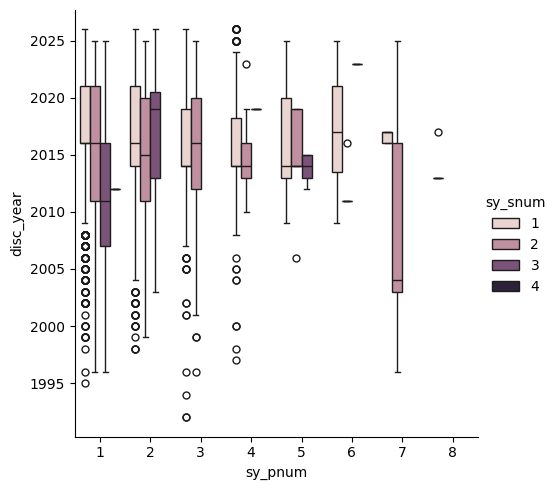

In [ ]:
sns.catplot(y="disc_year", x="sy_pnum", hue="sy_snum", data=data, kind="box");

Los datos aportados por la NASA acerca de exoplanetas están llenos de valores nulos, debido a que, dependiendo de la técnica de estudio, se consiguen más información acerca de cada exoplaneta. Debemos identificar los valores nulos y manejarlos. Nos hemos decantado por la eliminación de aquellas filas donde se muestren ciertos valores nulos.

In [ ]:
data.isna().sum()

,0
pl_name,0
hostname,0
sy_snum,0
sy_pnum,0
discoverymethod,0
disc_year,0
disc_facility,0
soltype,0
pl_orbper,598
pl_orbsmax,2351


In [ ]:
values = ["pl_orbper", "pl_orbsmax", "pl_rade", "pl_bmasse","pl_orbeccen","pl_insol","pl_eqt","st_spectype","st_teff","st_rad", "st_mass", "st_met", "sy_dist", "sy_gaiamag"]
data2=data.dropna(subset=values)

Comprobamos que han desaparecido los valores nulos

In [ ]:
data2.isna().sum()

,0
pl_name,0
hostname,0
sy_snum,0
sy_pnum,0
discoverymethod,0
disc_year,0
disc_facility,0
soltype,0
pl_orbper,0
pl_orbsmax,0


Hemos sacado una gráfica bidimensional, donde se tiene en cuenta la magnitud GAIA (mide la intensidad de la luz estelar principalmente en banda ancha (G), cubriendo desde el espectro azul hasta el infrarrojo cercano (330-1050mm)), junto a la distancia al sistema solar desde la Tierrna (en pc). Además, se colorea un mapa de calor la temperatura efectiva estelar (en K). Se puede apreciar que las estrellas más cercanas (pc<100) tienen una baja temperatura efectiva.

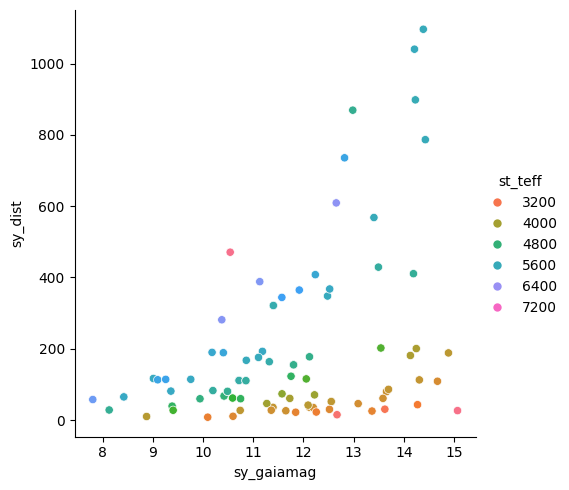

In [ ]:
sns.relplot(x="sy_gaiamag", y="sy_dist", hue="st_teff", palette="husl", data=data2);

También queríamos comprobar la metalicidad de las estrellas, comparandola junto a su radio y a la temperatura efectiva. No podemos sacar grandes conclusiones de este gráfico, la mayoría de estrellas tiene hierro.

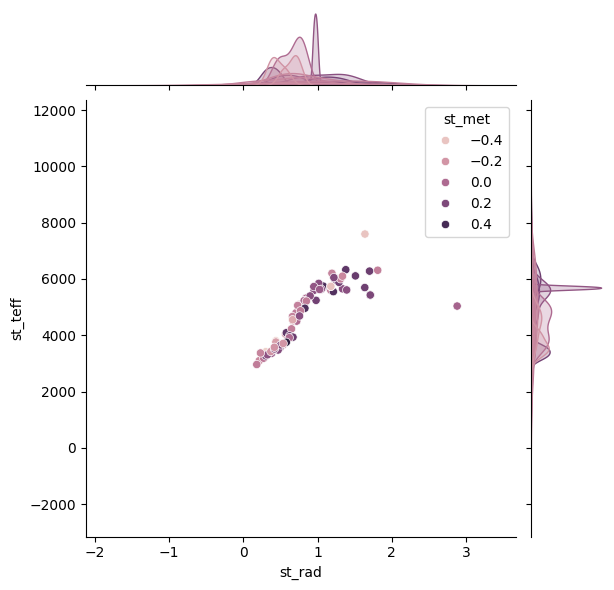

In [ ]:
sns.jointplot(x="st_rad", y="st_teff", hue="st_met", data=data2);

El mapa de calor nos permite ver la correlacción entre los datos obtenidos para los planeta y las estrella

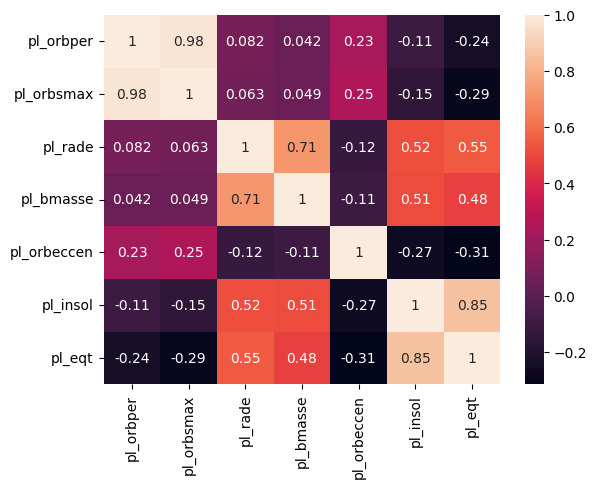

In [ ]:
sns.heatmap(data2.select_dtypes(include=['number']).corr(method='pearson').drop(
['sy_snum','sy_pnum','disc_year','st_teff','st_rad','st_mass','st_met','ra','dec','sy_dist','sy_gaiamag'], axis=1).drop(
    ['sy_snum','sy_pnum','disc_year','st_teff','st_rad','st_mass','st_met','ra','dec','sy_dist','sy_gaiamag'], axis=0),
			annot = True);

plt.show()

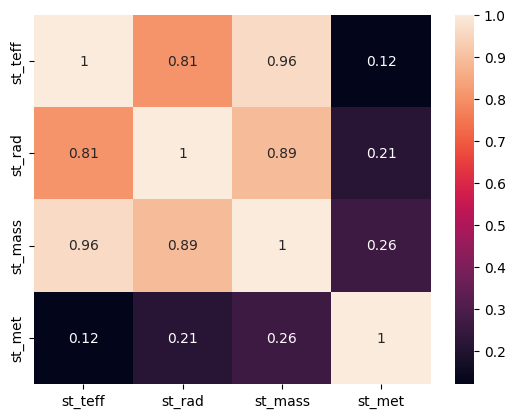

In [ ]:
sns.heatmap(data2.select_dtypes(include=['number']).corr(method='pearson').drop(
['sy_snum','sy_pnum','disc_year','pl_orbeccen','pl_orbper','pl_orbsmax','pl_bmasse','ra','dec','sy_dist','sy_gaiamag', 'pl_rade', 'pl_insol', 'pl_eqt'], axis=1).drop(
    ['sy_snum','sy_pnum','disc_year','pl_orbeccen','pl_orbper','pl_orbsmax','pl_bmasse','ra','dec','sy_dist','sy_gaiamag', 'pl_rade', 'pl_insol', 'pl_eqt'], axis=0),
			annot = True);

plt.show()